# Outlier Analysis, End to End
## Nova Cart — 500 orders, 10 columns

---

### The situation

Nova Cart is an online marketplace. It has exported six months of orders and
handed you the file with a short brief:

> *"Average order value looks wrong, and the delivery numbers make no sense.
> Also, customer ratings have dropped and nobody knows why. Can you look?"*

The file has **not** been cleaned. It is a realistic raw export. Finding what is
wrong with it is the work.

### How this notebook is organised

| Section | What happens |
|---|---|
| **1** | Read the data and check whether it says what it claims |
| **2** | Descriptive statistics — centre, spread, shape |
| **3** | Visualisation — see the shape before trusting any number |
| **4** | Outlier analysis, end to end |
| **5** | Findings and recommendations |

### The one idea to hold on to

An outlier is **not** the same thing as a mistake. There are three kinds, and
they need three different responses:

1. **A data error** — a typo, a placeholder, an impossible value. *Fix or remove.*
2. **Rare but genuine** — a real, extreme observation. *Keep it. It is a finding.*
3. **A different population** — normal for a group you did not know was there. *Segment.*

By the end of section 4 we will have found all three in this file.

*Run the cells in order. Each one is commented line by line.*

---

# 1. Reading the Data

Before analysing anything, three questions:

1. Did the file load the way I expected?
2. Is anything missing or duplicated?
3. **Does the file say what it claims to say?**

Question 3 is the one people skip, and it is where this file falls apart.

In [1]:
# ---------------------------------------------------------------------------
# IMPORTS
# ---------------------------------------------------------------------------
# pandas  -- tables of data. Anything shaped like a spreadsheet.
# numpy   -- fast maths on arrays of numbers.
# pyplot  -- the plotting library. "plt" is the universal short name for it.
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings. These do not change any results -- they only make the
# printed output readable so we are not squinting at scientific notation.
pd.set_option("display.max_columns", 30)      # never hide columns
pd.set_option("display.width", 140)           # allow wide output
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")   # 1,234.56

# Draw charts directly under the cell that creates them.
%matplotlib inline

# A consistent look for every chart in this notebook, set once here rather
# than repeated on every plot.
plt.rcParams.update({
    "figure.figsize": (10, 4.5),   # default size in inches
    "axes.spines.top": False,      # drop the top border of each chart
    "axes.spines.right": False,    # and the right border -- less clutter
    "axes.grid": True,             # faint gridlines aid reading values
    "grid.alpha": 0.25,
    "font.size": 10,
})

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ---------------------------------------------------------------------------
# LOAD THE DATA
# ---------------------------------------------------------------------------
# The file is available as both .xlsx and .csv -- identical contents.
# CSV loads faster and needs no extra library, so we use it by default.
#
# parse_dates=["order_date"] tells pandas to read that column as real dates
# rather than as text. Without it, sorting and date arithmetic silently break.
# ---------------------------------------------------------------------------
df = pd.read_csv("nova_cart_orders.csv", parse_dates=["order_date"])

# To use the Excel file instead, comment out the line above and use:
# df = pd.read_excel("nova_cart_orders.xlsx", sheet_name="Orders")

# .shape returns (rows, columns).
print(f"Rows loaded    : {df.shape[0]:,}")
print(f"Columns loaded : {df.shape[1]}")

# .head(n) shows the first n rows. Always eyeball the raw data before
# computing anything on it.
df.head()

Rows loaded    : 500
Columns loaded : 10


,order_id,order_date,product_category,customer_type,units,unit_price,order_value,shipping_cost,delivery_days,customer_rating
0,NC-20453,2026-01-01,Beauty,Returning,1,661.89,661.89,111.96,4.70,5
1,NC-20219,2026-01-01,Electronics,Returning,1,"5,494.66","5,494.66",119.22,1.00,4
2,NC-20243,2026-01-01,Apparel,Returning,2,453.01,906.02,161.54,4.50,5
3,NC-20329,2026-01-02,Electronics,New,1,"5,545.33","5,545.33",157.20,6.00,4
4,NC-20287,2026-01-02,Apparel,Wholesale,46,951.31,"43,760.26",147.33,5.00,3


In [3]:
# ---------------------------------------------------------------------------
# WHAT TYPE IS EACH COLUMN?
# ---------------------------------------------------------------------------
# Data type decides which statistics are even legal:
#
#   object / string  -> categories. Mode only. A mean is meaningless.
#   int64 / float64  -> numbers. Mean, median, standard deviation all valid.
#   datetime64       -> dates. Can be sorted and subtracted.
#
# A common bug: a numeric column arrives as text because one row contains
# something like "N/A". Every calculation on it then fails or silently lies.
# ---------------------------------------------------------------------------
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),          # count of filled values
    "nulls": df.isna().sum(),              # count of missing values
    "unique": df.nunique(),                # how many distinct values
})

summary

,dtype,non_null,nulls,unique
order_id,str,500,0,500
order_date,datetime64[us],500,0,163
product_category,str,500,0,5
customer_type,str,500,0,3
units,int64,500,0,35
unit_price,float64,500,0,499
order_value,float64,500,0,499
shipping_cost,float64,500,0,491
delivery_days,float64,500,0,84
customer_rating,int64,500,0,5


In [4]:
# ---------------------------------------------------------------------------
# MISSING VALUES AND DUPLICATES
# ---------------------------------------------------------------------------
# Two cheap checks that catch a surprising number of broken files.
# ---------------------------------------------------------------------------

# .isna() marks every cell True/False for "is this missing?".
# .sum().sum() adds up across columns and then across rows, giving one total.
total_missing = df.isna().sum().sum()

# .duplicated() marks rows identical to an earlier row.
duplicate_rows = df.duplicated().sum()

# order_id should be unique. If it is not, rows have been double-counted --
# which would inflate every total in the analysis.
duplicate_ids = df["order_id"].duplicated().sum()

print(f"Missing values anywhere : {total_missing}")
print(f"Fully duplicated rows   : {duplicate_rows}")
print(f"Duplicated order_ids    : {duplicate_ids}")

if total_missing == 0 and duplicate_rows == 0 and duplicate_ids == 0:
    print("\nClean on all three checks.")
    print("Note what this does NOT prove: a value can be present, unique,")
    print("and still be wrong. That is the next check.")

Missing values anywhere : 0
Fully duplicated rows   : 0
Duplicated order_ids    : 0

Clean on all three checks.
Note what this does NOT prove: a value can be present, unique,
and still be wrong. That is the next check.


### 1.1 The check that actually matters

No missing values and no duplicates. Most people would start analysing here.

But the data dictionary states a rule about this file:

> `order_value` should equal `units` × `unit_price`

That is a claim we can test. If a row breaks it, something is wrong with that
row — regardless of how complete or unique it looks.

In [5]:
# ---------------------------------------------------------------------------
# INTEGRITY CHECK: DOES THE FILE OBEY ITS OWN RULE?
# ---------------------------------------------------------------------------
# Recompute order_value from the two columns it is supposed to come from,
# then compare against the stored value.
#
# We round to 2 decimals because the file stores rupees and paise. Comparing
# floating point numbers for exact equality is unreliable, so we allow a
# tolerance of 1 paisa.
# ---------------------------------------------------------------------------
recomputed = (df["units"] * df["unit_price"]).round(2)

# .abs() makes the difference positive either way, so we catch errors in
# both directions -- too high and too low.
difference = (recomputed - df["order_value"]).abs()

# Any row off by more than 1 paisa fails the check.
fails_check = difference > 0.01

print(f"Rows that fail the check: {fails_check.sum()} out of {len(df)}")
print(f"Largest discrepancy     : {difference.max():,.2f}\n")

# Show the failing rows with the recomputed value alongside, so the size and
# direction of each error is visible.
broken = df.loc[fails_check, ["order_id", "product_category", "customer_type",
                              "units", "unit_price", "order_value"]].copy()
broken["should_be"] = recomputed[fails_check]
broken["ratio"] = (broken["order_value"] / broken["should_be"]).round(1)

broken

Rows that fail the check: 9 out of 500
Largest discrepancy     : 62,350.56



,order_id,product_category,customer_type,units,unit_price,order_value,should_be,ratio
6,NC-20396,Electronics,Returning,3,"2,309.28","69,278.40","6,927.84",10.00
89,NC-20410,Beauty,New,1,471.93,"4,719.30",471.93,10.00
95,NC-20186,Electronics,New,1,"4,594.40","51,839.34","4,594.40",11.30
180,NC-20258,Beauty,New,1,669.64,"49,951.35",669.64,74.60
242,NC-20489,Sports,New,1,777.78,"7,777.80",777.78,10.00
287,NC-20090,Apparel,Returning,1,"1,522.10","46,948.06","1,522.10",30.80
318,NC-20368,Beauty,Returning,4,0.00,"2,037.84",0.00,inf
364,NC-20274,Sports,Returning,3,0.00,"5,830.56",0.00,inf
451,NC-20072,Apparel,New,3,"1,503.07","45,092.10","4,509.21",10.00


**Nine rows fail, and they fail in three distinct patterns.** Read the `ratio`
column — it is the stored value divided by what it should be.

| Pattern | What it looks like | Almost certainly |
|---|---|---|
| `ratio` = 10.0 | value is exactly ten times too big | a typing error — an extra zero |
| `unit_price` = 0 | ratio is infinite | a missing price, stored as zero |
| `units` = 1, huge value | ratio is very large and not round | a data-entry fault |

None of these would have been caught by checking for missing values.

**The lesson:** "no nulls, no duplicates" means the file is *complete*, not that
it is *correct*. Whenever a dataset states a relationship between its columns,
test it.

In [6]:
# ---------------------------------------------------------------------------
# SCAN FOR IMPOSSIBLE VALUES
# ---------------------------------------------------------------------------
# Separate from statistics: some values are wrong on business logic alone,
# no matter how the rest of the data is distributed.
#
# We list the rules we expect to hold, then test each one. Writing them out
# explicitly is the point -- it forces you to state what "valid" means.
# ---------------------------------------------------------------------------
rules = {
    "units below 1":            df["units"] < 1,
    "unit_price of 0 or less":  df["unit_price"] <= 0,
    "order_value of 0 or less": df["order_value"] <= 0,
    "shipping_cost negative":   df["shipping_cost"] < 0,
    "delivery_days of 0":       df["delivery_days"] == 0,
    "delivery_days over 60":    df["delivery_days"] > 60,
    "rating outside 1-5":       ~df["customer_rating"].between(1, 5),
}

print("IMPOSSIBLE-VALUE SCAN")
print("-" * 46)
for description, mask in rules.items():
    count = mask.sum()          # True counts as 1, so .sum() counts the hits
    flag = "  <-- investigate" if count else ""
    print(f"  {description:<28} {count:>4}{flag}")

IMPOSSIBLE-VALUE SCAN
----------------------------------------------
  units below 1                   0
  unit_price of 0 or less         2  <-- investigate
  order_value of 0 or less        0
  shipping_cost negative          0
  delivery_days of 0              2  <-- investigate
  delivery_days over 60           3  <-- investigate
  rating outside 1-5              0


In [7]:
# ---------------------------------------------------------------------------
# WHAT ARE THOSE LONG DELIVERIES?
# ---------------------------------------------------------------------------
# The scan found deliveries over 60 days. Before assuming anything, look at
# the actual values. .nlargest(n) returns the n biggest entries.
# ---------------------------------------------------------------------------
print("Ten longest delivery times:")
print(df["delivery_days"].nlargest(10).to_string())

# .value_counts() counts how often each distinct value appears. If one exact
# number repeats, it is a placeholder rather than a measurement -- real
# durations do not land on the identical value again and again.
print("\nHow often does each of the top values occur?")
print(df.loc[df["delivery_days"] > 60, "delivery_days"].value_counts().to_string())

Ten longest delivery times:
218   999.00
239   999.00
388   999.00
87     28.50
260    28.00
351    25.70
268    22.00
447    21.90
493    14.70
77     14.00

How often does each of the top values occur?
delivery_days
999.00    3


### 1.2 A placeholder, not a delay

Three orders show a delivery time of **exactly 999.0 days**.

That is not a slow delivery. `999` is a **sentinel value** — a number a system
writes when the real value is unknown. Common sentinels: `999`, `-1`, `0`,
`9999`, `1900-01-01`.

The giveaway is the exact repetition. Genuine durations vary; a placeholder does
not. Section 2 shows what these three rows do to the statistics.

We now have our first outliers, and they are **kind 1: data errors.**

---

# 2. Descriptive Statistics

Four questions about any numeric column:

| Question | Statistic |
|---|---|
| Where is the centre? | mean, median |
| How spread out is it? | standard deviation, IQR |
| Is it symmetric? | skewness |
| How heavy are the tails? | kurtosis |

We answer all four for every numeric column, then read the answers.

In [8]:
# ---------------------------------------------------------------------------
# THE STANDARD SUMMARY
# ---------------------------------------------------------------------------
# .describe() is the fastest first look at every numeric column: count, mean,
# standard deviation, min, the three quartiles, and max.
#
# .T transposes the result so columns run down the page instead of across,
# which is far easier to read when there are several of them.
# ---------------------------------------------------------------------------
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,500,2026-04-02 07:58:04.800000,2026-01-01 00:00:00,2026-02-18 18:00:00,2026-04-03 12:00:00,2026-05-18 00:00:00,2026-06-29 00:00:00,NaN
units,500.00,6.02,1.00,1.00,2.00,3.00,60.00,12.38
unit_price,500.00,"1,681.05",0.00,661.73,"1,055.45","1,849.58","15,608.59","1,889.92"
order_value,500.00,"8,965.78",290.84,"1,168.82","2,334.91","5,415.07","506,935.24","29,277.02"
shipping_cost,500.00,151.11,77.50,131.74,148.98,170.67,240.51,29.53
delivery_days,500.00,10.51,0.00,3.50,4.40,5.10,999.00,76.92
customer_rating,500.00,3.99,1.00,3.00,4.00,5.00,5.00,1.08


**Two rows here should stop you.**

**`delivery_days`** — the mean is about 10.5 days but the 75th percentile is
about 5.3. Three quarters of orders arrive within roughly 5 days, yet the
average says 10.5. A mean sitting far above the 75th percentile is a signature
of contamination.

**`order_value`** — the mean is roughly four times the median. That is a long
right tail. It may be genuine, or it may be those 10× typos, and we do not yet
know which.

The `describe()` output tells you *that* something is wrong. It does not tell you
*what*.

In [9]:
# ---------------------------------------------------------------------------
# A FULLER PROFILE: ALL FOUR QUESTIONS AT ONCE
# ---------------------------------------------------------------------------
# describe() covers centre and spread but not SHAPE. Skewness and kurtosis are
# what tell you whether the mean is safe to report at all, so we build our own
# summary that includes them.
# ---------------------------------------------------------------------------

# select_dtypes picks columns by type. "number" grabs every int and float,
# so the function keeps working if columns are added later.
numeric_columns = df.select_dtypes(include="number").columns.tolist()


def profile(frame, columns):
    """Return centre, spread and shape for each column given."""
    rows = []
    for name in columns:
        series = frame[name]
        q1 = series.quantile(0.25)      # 25% of values fall below this
        q3 = series.quantile(0.75)      # 75% fall below this
        rows.append({
            "column": name,
            "mean": series.mean(),
            "median": series.median(),
            # A mean far from the median is the fastest shape diagnostic there
            # is. Expressed as a ratio so it compares across different scales.
            "mean/median": series.mean() / series.median() if series.median() else np.nan,
            "std": series.std(),
            "IQR": q3 - q1,
            # skew: 0 is symmetric, positive means a long right tail.
            "skew": series.skew(),
            # kurt: pandas returns EXCESS kurtosis, so 0 means normal-like
            # tails, not 3. This trips people up constantly.
            "excess_kurt": series.kurt(),
        })
    return pd.DataFrame(rows).set_index("column")


profile(df, numeric_columns).round(2)

,mean,median,mean/median,std,IQR,skew,excess_kurt
column,,,,,,,
units,6.02,2.00,3.01,12.38,2.00,2.88,7.11
unit_price,"1,681.05","1,055.45",1.59,"1,889.92","1,187.85",3.60,17.40
order_value,"8,965.78","2,334.92",3.84,"29,277.02","4,246.25",11.87,182.08
shipping_cost,151.11,148.98,1.01,29.53,38.93,0.13,-0.22
delivery_days,10.51,4.40,2.39,76.92,1.60,12.81,162.90
customer_rating,3.99,4.00,1.00,1.08,2.00,-0.85,-0.32


### 2.1 Reading the profile

**`delivery_days` is the worst offender.** Skewness of about 12.8 and excess
kurtosis in the hundreds. For reference, a symmetric column scores near 0 on
both. The standard deviation is roughly 77 days — larger than any delivery that
has ever actually happened here.

**`order_value` is severely right-skewed**, with a mean about 3.8× the median.

**`shipping_cost` is well behaved** — skewness near 0, excess kurtosis near 0,
mean and median almost identical. Keep this column in mind: it is the control
that shows what a clean column looks like.

**`customer_rating` is left-skewed** (skewness about −0.85). Most customers rate
highly and a minority rate very low. Opposite direction to order value, same
underlying idea.

Now let us quantify the damage those three sentinel rows are doing.

In [10]:
# ---------------------------------------------------------------------------
# THE COST OF THREE BAD ROWS
# ---------------------------------------------------------------------------
# Compare the delivery statistics with and without the 999 placeholders.
# We are not cleaning the data yet -- just measuring the impact.
# ---------------------------------------------------------------------------

# A boolean mask: True for every row whose delivery time is a real measurement.
is_real = df["delivery_days"] < 900

contaminated = df["delivery_days"]              # all 500 rows
clean = df.loc[is_real, "delivery_days"]        # 497 rows

comparison = pd.DataFrame({
    "with 3 placeholders": [
        len(contaminated), contaminated.mean(), contaminated.median(),
        contaminated.std(), contaminated.skew(), contaminated.max(),
    ],
    "without them": [
        len(clean), clean.mean(), clean.median(),
        clean.std(), clean.skew(), clean.max(),
    ],
}, index=["n", "mean", "median", "std dev", "skewness", "max"])

# How much each statistic moved, as a multiple.
comparison["distortion"] = (
    comparison["with 3 placeholders"] / comparison["without them"]
).round(1)

comparison.round(2)

,with 3 placeholders,without them,distortion
n,500.00,497.00,1.00
mean,10.51,4.54,2.30
median,4.40,4.30,1.00
std dev,76.92,2.71,28.40
skewness,12.81,4.89,2.60
max,999.00,28.50,35.10


### 2.2 Three rows out of 500

**0.6% of the data moved the mean by 2.3× and the standard deviation by 28×.**

The median barely moved — from 4.40 to 4.40. That is the median doing exactly
what it is built to do: it counts positions, so the *size* of a wrong value is
irrelevant to it.

This is the practical case for reporting the median alongside the mean. **When
the two disagree sharply, the disagreement is itself the finding.** Here it was
pointing at three broken rows.

The standard deviation is the most fragile statistic on the page. It is built
from squared distances, so one absurd value dominates it completely.

In [11]:
# ---------------------------------------------------------------------------
# THE CATEGORICAL COLUMNS
# ---------------------------------------------------------------------------
# Text columns cannot have a mean or a median -- there is no ordering to a
# payment method or a category name. The mode (most frequent value) and the
# counts are the whole story.
# ---------------------------------------------------------------------------
for column in ["product_category", "customer_type"]:
    counts = df[column].value_counts()
    # normalize=True gives shares instead of raw counts.
    shares = df[column].value_counts(normalize=True)

    print(f"\n{column.upper()}")
    print("-" * 42)
    for level in counts.index:
        # A simple text bar makes relative size visible without a chart.
        bar = "#" * int(shares[level] * 50)
        print(f"  {level:<16} {counts[level]:>4}  {shares[level]:>6.1%}  {bar}")


PRODUCT_CATEGORY
------------------------------------------
  Apparel           130   26.0%  #############
  Home & Living     113   22.6%  ###########
  Electronics       100   20.0%  ##########
  Beauty             99   19.8%  #########
  Sports             58   11.6%  #####

CUSTOMER_TYPE
------------------------------------------
  New               225   45.0%  ######################
  Returning         220   44.0%  ######################
  Wholesale          55   11.0%  #####


### 2.3 A third customer type

`customer_type` has three levels, not two: **New**, **Returning**, and
**Wholesale** — the last making up about 11% of orders.

Wholesale buyers are a different business. They buy in bulk at a lower unit
price. If they are sitting inside the same column as retail customers, then every
statistic computed so far describes a blend of two unrelated things.

Let us check whether that matters.

In [12]:
# ---------------------------------------------------------------------------
# DOES CUSTOMER TYPE SPLIT THE DATA?
# ---------------------------------------------------------------------------
# .groupby(column) splits the table into groups, then .agg() computes the
# same statistics within each group. This is the workhorse of exploratory
# analysis in pandas.
# ---------------------------------------------------------------------------
by_type = df.groupby("customer_type").agg(
    orders=("order_id", "count"),
    median_units=("units", "median"),
    median_price=("unit_price", "median"),
    median_value=("order_value", "median"),
    mean_value=("order_value", "mean"),
)

# Revenue share matters as much as order share: a small group can dominate
# the totals.
revenue = df.groupby("customer_type")["order_value"].sum()
by_type["revenue_share"] = (revenue / revenue.sum() * 100).round(1)

print(by_type.round(0).to_string())

retail_median = df.loc[df["customer_type"] != "Wholesale", "order_value"].median()
wholesale_median = df.loc[df["customer_type"] == "Wholesale", "order_value"].median()

print(f"\nRetail median order    : {retail_median:>10,.0f}")
print(f"Wholesale median order : {wholesale_median:>10,.0f}")
print(f"Wholesale is {wholesale_median / retail_median:.0f}x larger.")

               orders  median_units  median_price  median_value  mean_value  revenue_share
customer_type                                                                             
New               225          2.00      1,190.00      1,938.00    3,942.00          20.00
Returning         220          2.00      1,064.00      1,985.00    3,731.00          18.00
Wholesale          55         40.00        817.00     35,121.00   50,455.00          62.00

Retail median order    :      1,961
Wholesale median order :     35,121
Wholesale is 18x larger.


### 2.4 Two businesses in one file

Wholesale orders have a median about **18× larger** than retail, and 11% of
orders produce a large share of revenue.

This is **kind 3** from the introduction: values that look extreme only because
a second population is hiding in the same column.

We now have two of the three kinds. Section 4 confirms the third.

---

# 3. Visualisation

Statistics compress a column into a few numbers, and compression loses
information. Two columns can share a mean and a standard deviation and look
nothing alike.

**Always look at the shape before trusting a summary of it.**

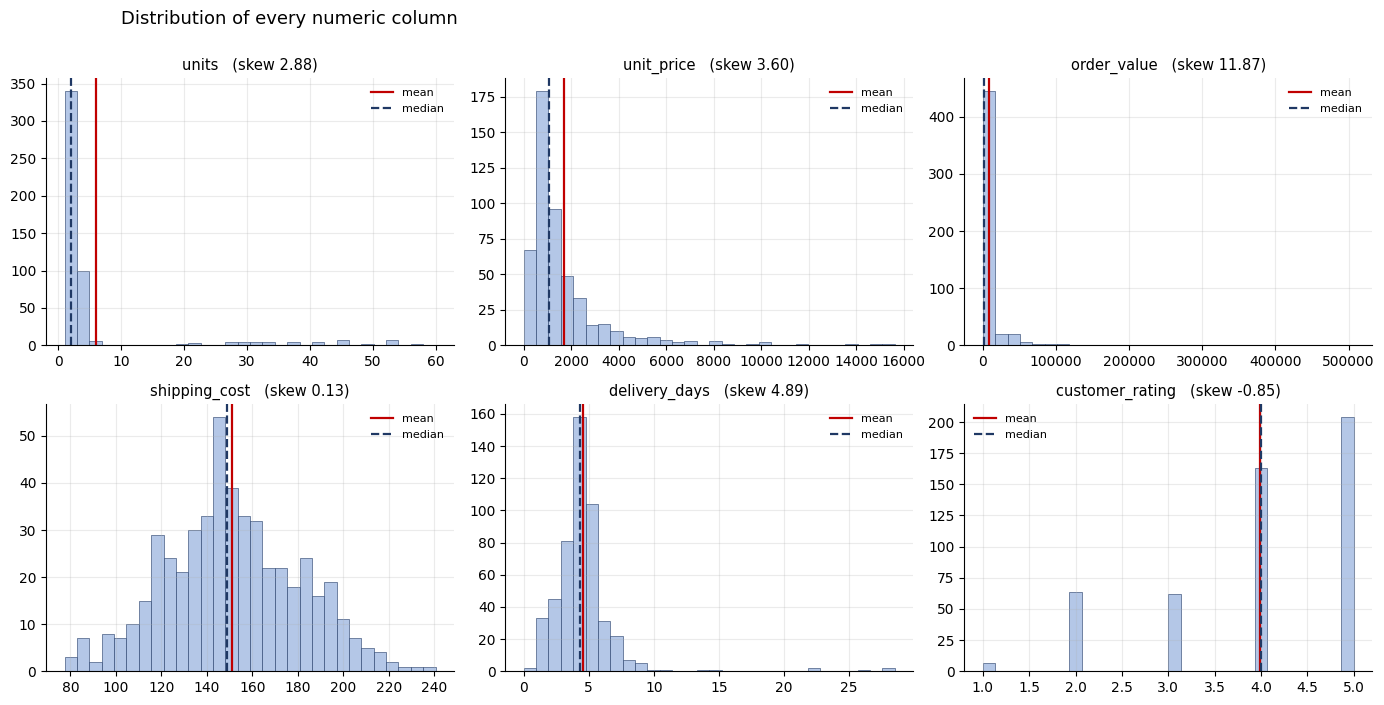

In [13]:
# ---------------------------------------------------------------------------
# HISTOGRAMS OF EVERY NUMERIC COLUMN
# ---------------------------------------------------------------------------
# A histogram splits the range into bins and counts how many values land in
# each. It is the fastest way to see shape: one peak or two, symmetric or
# skewed, where the mass sits.
#
# We plot the CLEAN delivery column here (excluding the 999s). Left in, they
# would stretch the axis so far that all 497 real values would collapse into
# a single bar -- which is itself worth demonstrating, and we do that next.
# ---------------------------------------------------------------------------
plot_columns = ["units", "unit_price", "order_value",
                "shipping_cost", "delivery_days", "customer_rating"]

# A grid of 2 rows x 3 columns of charts.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# .ravel() flattens the 2x3 grid into a flat list so we can loop over it.
for ax, column in zip(axes.ravel(), plot_columns):
    # Use only real delivery values for that one column.
    values = df.loc[df["delivery_days"] < 900, column] if column == "delivery_days" else df[column]

    ax.hist(values, bins=30, color="#B4C7E7", edgecolor="#1F3864", linewidth=0.4)

    # Mark the mean and median. Where they sit relative to each other is the
    # visual version of the skewness number from section 2.
    ax.axvline(values.mean(), color="#C00000", linewidth=1.6, label="mean")
    ax.axvline(values.median(), color="#1F3864", linewidth=1.6,
               linestyle="--", label="median")

    ax.set_title(f"{column}   (skew {values.skew():.2f})", fontsize=10.5)
    ax.legend(fontsize=8, frameon=False)

fig.suptitle("Distribution of every numeric column", fontsize=13, x=0.09,
             ha="left", y=1.00)
fig.tight_layout()
plt.show()

### 3.1 What the histograms show

**`order_value` and `units`** — steep right skew. Most orders are small, a few
are very large. The red mean line sits well to the right of the dashed median,
which is what right skew looks like.

**`shipping_cost`** — symmetric and bell-shaped. Mean and median sit on top of
each other. This is the control column: it is what "well behaved" looks like.

**`delivery_days`** (placeholders removed) — mostly tidy with a thin right tail.

**`customer_rating`** — piled up at 4 and 5 with a group down at 1 and 2. The
mean line falls in a gap where relatively few customers actually sit, which is
why an average rating is a poor dashboard metric.

Now, the same delivery column with the three placeholders left in.

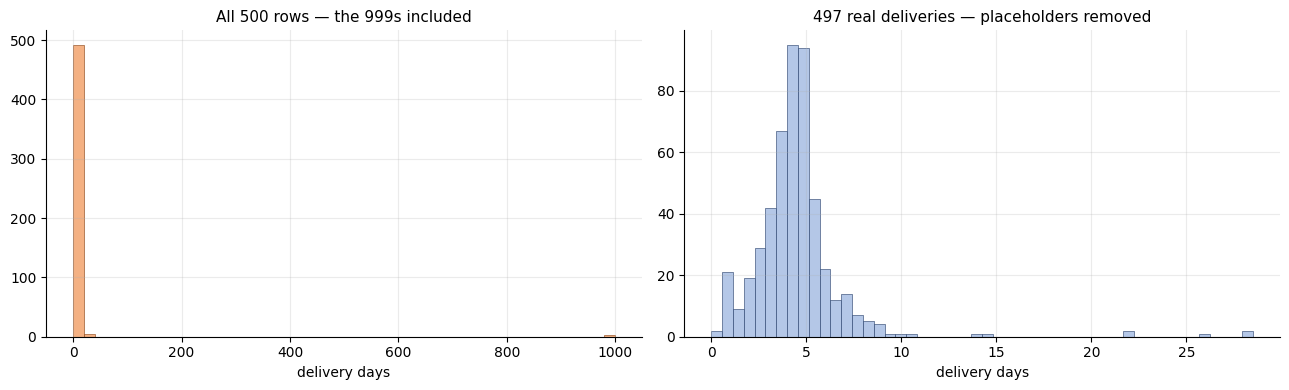

Left  : 497 orders squashed into the first bar, 3 orders visible at 999.
Right : the actual distribution, which was there the whole time.


In [14]:
# ---------------------------------------------------------------------------
# WHAT THREE BAD ROWS DO TO A CHART
# ---------------------------------------------------------------------------
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4))

# LEFT: every row, placeholders included.
ax_left.hist(df["delivery_days"], bins=50, color="#F4B183", edgecolor="#843C0C",
             linewidth=0.4)
ax_left.set_title("All 500 rows — the 999s included", fontsize=11)
ax_left.set_xlabel("delivery days")

# RIGHT: real measurements only.
real = df.loc[df["delivery_days"] < 900, "delivery_days"]
ax_right.hist(real, bins=50, color="#B4C7E7", edgecolor="#1F3864", linewidth=0.4)
ax_right.set_title(f"497 real deliveries — placeholders removed", fontsize=11)
ax_right.set_xlabel("delivery days")

fig.tight_layout()
plt.show()

print("Left  : 497 orders squashed into the first bar, 3 orders visible at 999.")
print("Right : the actual distribution, which was there the whole time.")

### 3.2 The chart that shows nothing

The left chart is technically correct and completely useless. Three rows out of
500 stretched the axis so far that the other 497 collapsed into a single bar.

**This is why plotting comes before analysis, not after.** One look would have
caught the sentinel values in seconds — faster than any statistic did.

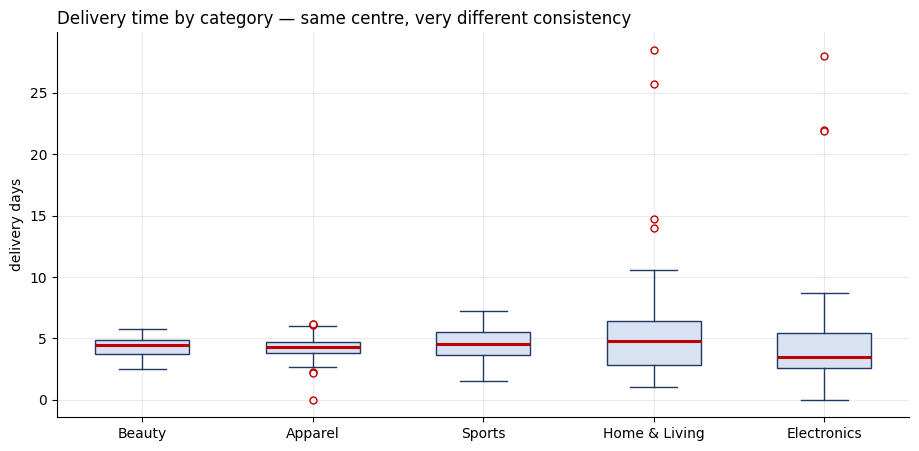

                  orders  mean  median  std  IQR
product_category                                
Apparel              130  4.27    4.30 0.83 0.90
Beauty                98  4.30    4.50 0.72 1.18
Electronics           99  4.43    3.50 4.05 2.85
Home & Living        112  5.21    4.80 3.95 3.60
Sports                58  4.44    4.55 1.35 1.88


In [15]:
# ---------------------------------------------------------------------------
# BOX PLOTS: COMPARING GROUPS
# ---------------------------------------------------------------------------
# A box plot is the IQR method drawn:
#     box    = Q1 to Q3, holding the middle 50%
#     line   = the median
#     whisker= the furthest real value still inside the fence
#     dots   = values outside the fence
#
# Side by side, box plots compare groups better than any table.
# ---------------------------------------------------------------------------
clean_delivery = df[df["delivery_days"] < 900]

# Order the categories by spread so the chart tells a story left to right.
order = (clean_delivery.groupby("product_category")["delivery_days"]
         .std().sort_values().index.tolist())

groups = [clean_delivery.loc[clean_delivery["product_category"] == c,
                             "delivery_days"].values for c in order]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(groups, tick_labels=order, patch_artist=True, widths=0.55)

# Style the elements so the median stands out from the box.
for patch in bp["boxes"]:
    patch.set_facecolor("#D9E2F3")
    patch.set_edgecolor("#1F3864")
for element in ["whiskers", "caps"]:
    for line in bp[element]:
        line.set_color("#1F3864")
for line in bp["medians"]:
    line.set_color("#C00000")
    line.set_linewidth(2.2)
for flier in bp["fliers"]:
    flier.set(marker="o", markersize=5, markerfacecolor="white",
              markeredgecolor="#C00000")

ax.set_ylabel("delivery days")
ax.set_title("Delivery time by category — same centre, very different consistency",
             fontsize=12, loc="left")
plt.show()

# The numbers behind the picture.
stats_by_category = clean_delivery.groupby("product_category")["delivery_days"].agg(
    orders="count", mean="mean", median="median", std="std")
stats_by_category["IQR"] = clean_delivery.groupby("product_category")["delivery_days"].apply(
    lambda s: s.quantile(0.75) - s.quantile(0.25))

print(stats_by_category.round(2).to_string())

### 3.3 Same average, different operations

Look at the **means**: four of the five categories sit between 4.27 and 4.44
days. On the average alone they are interchangeable.

Look at the **IQR**: Beauty and Apparel are around 0.9 to 1.2 days. Electronics
and Home & Living are around 2.9 to 3.6 — roughly three times wider.

Beauty ships from one reliable warehouse. Electronics and Home & Living come from
several suppliers, and it shows in the spread, not in the average.

**A promise is a statement about the worst case, not the average.** If Nova Cart
advertises a delivery window, Beauty can support a tighter one than Electronics
even though their averages match.

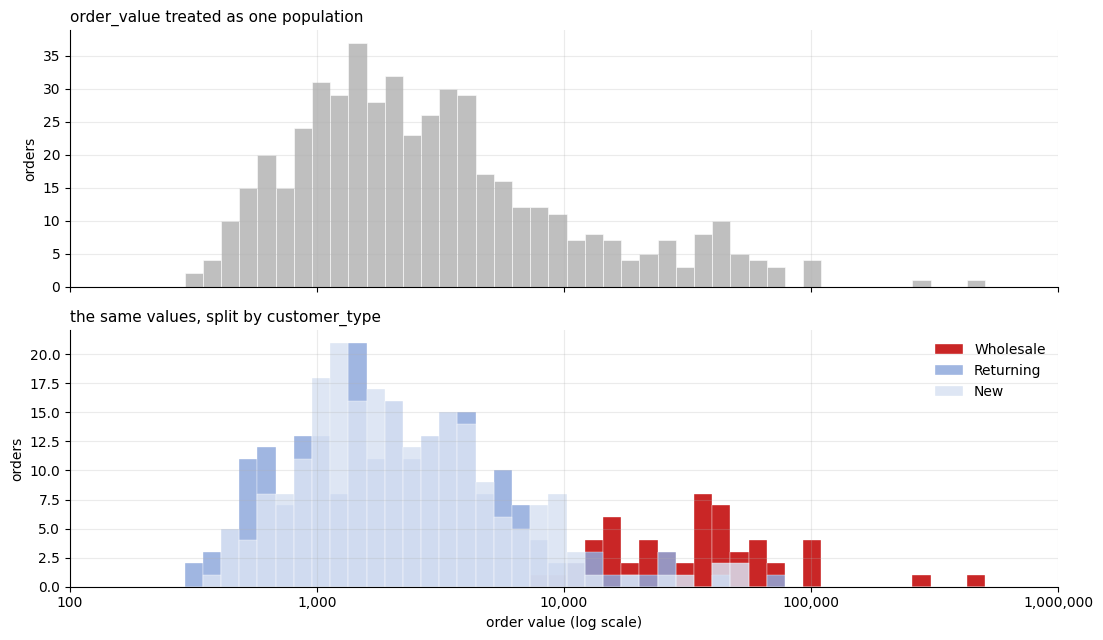

In [16]:
# ---------------------------------------------------------------------------
# ORDER VALUE ON A LOG SCALE, SPLIT BY CUSTOMER TYPE
# ---------------------------------------------------------------------------
# order_value spans four orders of magnitude, so on a normal axis everything
# bunches against the left edge. Plotting log10 of the value spreads it out:
# each equal step on the axis is a 10x increase.
# ---------------------------------------------------------------------------
logged = np.log10(df["order_value"])
bins = np.linspace(logged.min(), logged.max(), 45)

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# TOP: the column as a single population -- what you see by default.
ax_top.hist(logged, bins=bins, color="#BFBFBF", edgecolor="white", linewidth=0.4)
ax_top.set_title("order_value treated as one population", fontsize=11, loc="left")
ax_top.set_ylabel("orders")

# BOTTOM: the same values, split on a column already in the file.
for label, colour in [("Wholesale", "#C00000"), ("Returning", "#8FAADC"),
                      ("New", "#D9E2F3")]:
    subset = np.log10(df.loc[df["customer_type"] == label, "order_value"])
    ax_bottom.hist(subset, bins=bins, alpha=0.85, label=label,
                   color=colour, edgecolor="white", linewidth=0.3)

ax_bottom.set_title("the same values, split by customer_type",
                    fontsize=11, loc="left")
ax_bottom.set_ylabel("orders")
ax_bottom.set_xlabel("order value (log scale)")
ax_bottom.legend(frameon=False)

# Label the axis in rupees rather than log units.
ticks = [2, 3, 4, 5, 6]
ax_bottom.set_xticks(ticks)
ax_bottom.set_xticklabels([f"{10 ** t:,.0f}" for t in ticks])

fig.tight_layout()
plt.show()

### 3.4 The high values are a customer segment

The top panel looks like one long-tailed distribution. The bottom panel shows the
red Wholesale block occupying the right-hand side almost by itself.

Those large orders are not anomalies. **They are a customer type**, recorded in a
column that was in the file all along.

Notice how hard this was to see from the top panel alone. You needed a column
you already had, plus someone thinking to check.

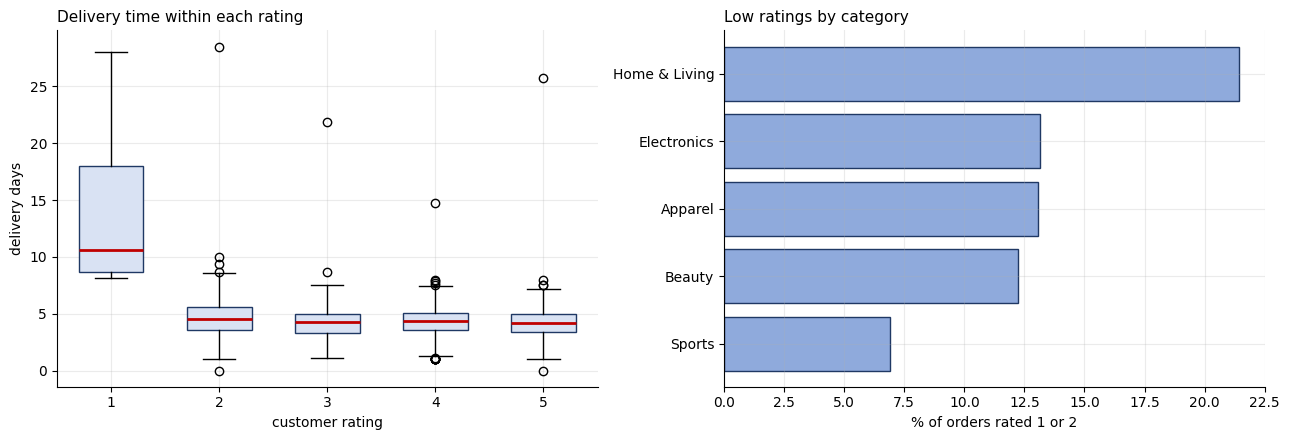

           orders  mean_days  median_days
rated 3-5     427       4.31         4.30
rated 1-2      70       5.95         4.60


In [17]:
# ---------------------------------------------------------------------------
# DOES SLOW DELIVERY EXPLAIN THE RATINGS?
# ---------------------------------------------------------------------------
# The brief said ratings dropped and nobody knew why. We have a delivery
# column, so we can test whether the two are related.
# ---------------------------------------------------------------------------
clean = df[df["delivery_days"] < 900]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 4.5))

# LEFT: a box plot of delivery time within each rating level. This shows the
# whole distribution per rating, not just an average.
levels = sorted(clean["customer_rating"].unique())
groups = [clean.loc[clean["customer_rating"] == r, "delivery_days"].values
          for r in levels]

bp = ax_left.boxplot(groups, tick_labels=levels, patch_artist=True, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor("#D9E2F3")
    patch.set_edgecolor("#1F3864")
for line in bp["medians"]:
    line.set_color("#C00000")
    line.set_linewidth(2)

ax_left.set_xlabel("customer rating")
ax_left.set_ylabel("delivery days")
ax_left.set_title("Delivery time within each rating", fontsize=11, loc="left")

# RIGHT: share of low ratings by category.
low_rate = (clean.assign(low=clean["customer_rating"] <= 2)
            .groupby("product_category")["low"].mean().sort_values() * 100)

ax_right.barh(low_rate.index, low_rate.values, color="#8FAADC",
              edgecolor="#1F3864")
ax_right.set_xlabel("% of orders rated 1 or 2")
ax_right.set_title("Low ratings by category", fontsize=11, loc="left")

fig.tight_layout()
plt.show()

# Quantify it rather than relying on the eye.
summary = clean.groupby(clean["customer_rating"] <= 2)["delivery_days"].agg(
    orders="count", mean_days="mean", median_days="median")
summary.index = ["rated 3-5", "rated 1-2"]
print(summary.round(2).to_string())

### 3.5 The ratings question, answered

Orders rated 1 or 2 took noticeably longer to arrive than orders rated 3 to 5,
and the low ratings concentrate in the two categories with the widest delivery
spread.

**This is a logistics problem presenting as a satisfaction problem.** No amount
of work on the review process will fix it. Fixing the delivery tail will.

---

# 4. Outlier Analysis, End to End

Everything so far has been preparation. Now the method.

**The IQR fence:**

```
IQR         = Q3 − Q1
lower fence = Q1 − 1.5 × IQR
upper fence = Q3 + 1.5 × IQR
```

Anything outside the fences is **flagged**. Flagged means *go and look*, not
*delete*.

**Why quartiles and not the mean?** Q1 and Q3 are positions. An extreme value
cannot drag them, so it cannot inflate the fence that is meant to catch it.

**What to expect:** on well-behaved data this flags about **0.7%** of rows. Far
more than that means the assumption behind the method has failed — and that is a
finding in itself.

In [18]:
# ---------------------------------------------------------------------------
# THE IQR FENCE, AS A REUSABLE FUNCTION
# ---------------------------------------------------------------------------
def iqr_fences(series, multiplier=1.5):
    """
    Return (lower_fence, upper_fence) for a numeric column.

    multiplier=1.5 is the standard convention, calibrated to flag roughly the
    most extreme 0.7% of well-behaved data.
    multiplier=3.0 flags only extreme outliers -- about 1 in 400,000.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - multiplier * iqr, q3 + multiplier * iqr


def flag_outliers(frame, column, multiplier=1.5):
    """Return a True/False mask marking rows outside the fences."""
    lower, upper = iqr_fences(frame[column], multiplier)
    # The | symbol means OR. Each condition needs its own brackets.
    return (frame[column] < lower) | (frame[column] > upper)


# Apply to every numeric column and collect the results in one table.
results = []
for column in numeric_columns:
    lower, upper = iqr_fences(df[column])
    mask = flag_outliers(df, column)
    results.append({
        "column": column,
        "Q1": df[column].quantile(0.25),
        "Q3": df[column].quantile(0.75),
        "IQR": df[column].quantile(0.75) - df[column].quantile(0.25),
        "lower_fence": lower,
        "upper_fence": upper,
        "flagged": mask.sum(),
        "flagged_pct": mask.mean() * 100,
    })

fence_table = pd.DataFrame(results).set_index("column")
fence_table.round(2)

,Q1,Q3,IQR,lower_fence,upper_fence,flagged,flagged_pct
column,,,,,,,
units,1.00,3.00,2.00,-2.00,6.00,55,11.00
unit_price,661.73,"1,849.58","1,187.85","-1,120.04","3,631.35",47,9.40
order_value,"1,168.82","5,415.07","4,246.25","-5,200.56","11,784.45",70,14.00
shipping_cost,131.74,170.67,38.93,73.34,229.07,2,0.40
delivery_days,3.50,5.10,1.60,1.10,7.50,52,10.40
customer_rating,3.00,5.00,2.00,0.00,8.00,0,0.00


### 4.1 Reading the flag rates

Compare each `flagged_pct` against the **0.7%** we expect from well-behaved data.

**`shipping_cost`** flags a low percentage — close to expectation. This column is
genuinely clean, which is exactly what section 3 showed.

**`order_value`, `units`, `unit_price`** flag double-digit percentages. Ten to
twenty times more than expected. Something structural is going on, and we already
know what: the Wholesale segment.

**`customer_rating`** flags nothing at all — its lower fence sits below 1, so no
rating can ever fall outside it. That is the formula telling you something true:
on a bounded 1–5 scale, no single rating is unusual.

**A high flag rate is not a list of things to delete.** It is a signal that the
method's assumption — one population, roughly continuous — does not hold.

In [19]:
# ---------------------------------------------------------------------------
# STEP 6: INVESTIGATE. WHICH KIND IS EACH FLAG?
# ---------------------------------------------------------------------------
# Take the flagged order_value rows and break them down by customer type.
# If they were random anomalies they would spread across all three types in
# proportion to how common each type is.
# ---------------------------------------------------------------------------
value_flags = flag_outliers(df, "order_value")

breakdown = pd.DataFrame({
    "flagged": df.loc[value_flags, "customer_type"].value_counts(),
    "total in data": df["customer_type"].value_counts(),
})
breakdown["% of that type flagged"] = (
    breakdown["flagged"] / breakdown["total in data"] * 100).round(1)
breakdown["share of all flags"] = (
    breakdown["flagged"] / value_flags.sum() * 100).round(1)

print(f"order_value flagged {value_flags.sum()} rows "
      f"({value_flags.mean():.1%} of the data)\n")
print(breakdown.fillna(0).to_string())

order_value flagged 70 rows (14.0% of the data)

               flagged  total in data  % of that type flagged  share of all flags
customer_type                                                                    
New                  8            225                    3.60               11.40
Returning           11            220                    5.00               15.70
Wholesale           51             55                   92.70               72.90


### 4.2 The flags are a customer segment

Wholesale is around 11% of orders but supplies the large majority of the flagged
rows, and a very high share of all Wholesale orders get flagged.

These are **kind 3** outliers: normal values from a population we were not
separating. Deleting them would delete the most valuable customers in the file.

The correct response is not to remove them. It is to **run the analysis within
each segment**.

In [20]:
# ---------------------------------------------------------------------------
# THE SAME METHOD, APPLIED WITHIN EACH SEGMENT
# ---------------------------------------------------------------------------
# Splitting first, then flagging, gives every group a fence built from its own
# spread -- rather than one fence that fits neither group.
# ---------------------------------------------------------------------------
rows = []
for segment, group in df.groupby("customer_type"):
    lower, upper = iqr_fences(group["order_value"])
    mask = (group["order_value"] < lower) | (group["order_value"] > upper)
    rows.append({
        "segment": segment,
        "orders": len(group),
        "median": group["order_value"].median(),
        "IQR": group["order_value"].quantile(0.75) - group["order_value"].quantile(0.25),
        "upper_fence": upper,
        "flagged": mask.sum(),
        "flagged_pct": mask.mean() * 100,
    })

segmented = pd.DataFrame(rows).set_index("segment")
print(segmented.round(1).to_string())

combined_pct = flag_outliers(df, "order_value").mean() * 100
print(f"\nOne fence for everyone : {combined_pct:.1f}% flagged")
print(f"Fences per segment     : {segmented['flagged'].sum() / len(df) * 100:.1f}% flagged")
print("\nSame data, same method. The only change is asking the question")
print("within each group instead of across a mixture of groups.")

           orders    median       IQR  upper_fence  flagged  flagged_pct
segment                                                                 
New           225  1,937.60  2,865.60     8,331.40       19         8.40
Returning     220  1,984.80  2,978.90     8,438.30       15         6.80
Wholesale      55 35,121.00 32,596.60    98,609.10        4         7.30

One fence for everyone : 14.0% flagged
Fences per segment     : 7.6% flagged

Same data, same method. The only change is asking the question
within each group instead of across a mixture of groups.


### 4.3 Segmenting fixes most of it

Splitting first drops the flag rate sharply, and the fences are now sensible for
each group — a Wholesale fence far above a retail one, because Wholesale orders
genuinely are larger.

Note the fences differ enormously between segments. **A fence is built from its
own group's spread**, which is exactly why comparing raw outlier counts across
groups is meaningless.

In [21]:
# ---------------------------------------------------------------------------
# THE MULTIVARIATE BLIND SPOT
# ---------------------------------------------------------------------------
# Every check so far looked at ONE column at a time. Some bad rows are
# unremarkable in each column and impossible in combination.
#
# The check: value per unit. It should equal unit_price on every row.
# ---------------------------------------------------------------------------
df_check = df.copy()
df_check["value_per_unit"] = (df_check["order_value"] / df_check["units"]).round(2)

# The rows that failed the reconciliation test back in section 1.
mismatch = (df_check["value_per_unit"] - df_check["unit_price"]).abs() > 0.01

print(f"Rows where value_per_unit does not match unit_price: {mismatch.sum()}\n")

# For each of those rows, check whether the single columns would have caught it.
suspects = df_check.loc[mismatch, ["order_id", "customer_type", "units",
                                   "unit_price", "order_value",
                                   "value_per_unit"]].copy()

units_lo, units_hi = iqr_fences(df["units"])
value_lo, value_hi = iqr_fences(df["order_value"])

suspects["units_flagged"] = (suspects["units"] < units_lo) | (suspects["units"] > units_hi)
suspects["value_flagged"] = (suspects["order_value"] < value_lo) | (suspects["order_value"] > value_hi)

print(suspects.to_string(index=False))

hidden = (~suspects["units_flagged"] & ~suspects["value_flagged"]).sum()
print(f"\n{hidden} of these rows are flagged by NEITHER single column.")
print("They are only visible in the relationship between two columns.")

Rows where value_per_unit does not match unit_price: 9

order_id customer_type  units  unit_price  order_value  value_per_unit  units_flagged  value_flagged
NC-20396     Returning      3    2,309.28    69,278.40       23,092.80          False           True
NC-20410           New      1      471.93     4,719.30        4,719.30          False          False
NC-20186           New      1    4,594.40    51,839.34       51,839.34          False           True
NC-20258           New      1      669.64    49,951.35       49,951.35          False           True
NC-20489           New      1      777.78     7,777.80        7,777.80          False          False
NC-20090     Returning      1    1,522.10    46,948.06       46,948.06          False           True
NC-20368     Returning      4        0.00     2,037.84          509.46          False          False
NC-20274     Returning      3        0.00     5,830.56        1,943.52          False          False
NC-20072           New      3    1,

### 4.4 Outliers that hide between columns

Some of these rows pass every single-column check and are still impossible.

`units` = 1 is the most common value in the file. An `order_value` of that size
is unremarkable for Wholesale. Only the **ratio** is wrong — one unit at a price
no catalogue item has.

**The practical takeaway:** whenever two columns should have a fixed
relationship, build the derived column and check *that*.

- value per unit
- shipping cost per unit
- revenue per customer
- price per kilogram

Formal multivariate methods exist. A derived column plus the same IQR fence
catches most of it and takes one line.

In [22]:
# ---------------------------------------------------------------------------
# IQR VERSUS Z-SCORE
# ---------------------------------------------------------------------------
# The z-score method flags anything more than 3 standard deviations from the
# mean. It has a structural weakness: the outlier inflates the very standard
# deviation used to judge it, raising the bar it then has to clear.
# ---------------------------------------------------------------------------
comparison_rows = []
for column in ["order_value", "delivery_days", "shipping_cost"]:
    series = df[column]

    # Z-score method.
    z = (series - series.mean()) / series.std()
    z_flags = z.abs() > 3

    # IQR method.
    iqr_flags = flag_outliers(df, column)

    comparison_rows.append({
        "column": column,
        "skewness": series.skew(),
        "z-score flags": z_flags.sum(),
        "IQR flags": iqr_flags.sum(),
        "z threshold": series.mean() + 3 * series.std(),
        "IQR threshold": iqr_fences(series)[1],
    })

print(pd.DataFrame(comparison_rows).set_index("column").round(2).to_string())

# The clearest demonstration: what each method does with delivery_days.
delivery = df["delivery_days"]
z_threshold = delivery.mean() + 3 * delivery.std()
iqr_threshold = iqr_fences(delivery)[1]

# The genuinely slow deliveries -- real operational failures, not errors.
genuine_slow = delivery[(delivery >= 14) & (delivery < 900)]

print(f"\nz-score threshold : {z_threshold:>7.1f} days")
print(f"IQR fence         : {iqr_threshold:>7.1f} days")
print(f"Slowest REAL delivery in the file: {delivery[delivery < 900].max():.1f} days")

print(f"\nThere are {len(genuine_slow)} genuinely slow deliveries "
      f"({genuine_slow.min():.0f} to {genuine_slow.max():.1f} days):")
print(f"  caught by the z-score rule : {(genuine_slow > z_threshold).sum()}")
print(f"  caught by the IQR fence    : {(genuine_slow > iqr_threshold).sum()}")

# Why the z-score threshold ended up so far out.
cleaned = delivery[delivery < 900]
print(f"\nThe three placeholders pushed the standard deviation to "
      f"{delivery.std():.1f} days,")
print(f"putting the 3-sigma threshold at {z_threshold:.0f} days -- beyond anything")
print(f"that can physically occur. Remove them first and the same threshold")
print(f"falls to {cleaned.mean() + 3 * cleaned.std():.1f} days.")

               skewness  z-score flags  IQR flags  z threshold  IQR threshold
column                                                                       
order_value       11.87              5         70    96,796.83      11,784.45
delivery_days     12.81              3         52       241.28           7.50
shipping_cost      0.13              1          2       239.68         229.07

z-score threshold :   241.3 days
IQR fence         :     7.5 days
Slowest REAL delivery in the file: 28.5 days

There are 7 genuinely slow deliveries (14 to 28.5 days):
  caught by the z-score rule : 0
  caught by the IQR fence    : 7

The three placeholders pushed the standard deviation to 76.9 days,
putting the 3-sigma threshold at 241 days -- beyond anything
that can physically occur. Remove them first and the same threshold
falls to 12.7 days.


### 4.5 The z-score method hides the real problem

The z-score rule catches the three placeholders — and **nothing else**.

Its threshold lands at roughly **241 days**. The slowest delivery that has ever
actually happened here is 28.5 days. So no real delivery can ever be flagged by
it, no matter how bad.

All **seven genuinely slow deliveries** — the ones between 14 and 28 days, the
actual operational failures the COO would want to know about — sail straight
through. The IQR fence catches every one.

**Why:** those three placeholder rows dragged the standard deviation up to about
77 days, and the z-score threshold is built from it. The bad rows raised the bar
high enough to hide every genuine problem behind them.

Remove the placeholders first and the same z-score threshold drops from 241 days
to about 13 — at which point it works fine.

| | IQR fence | Z-score |
|---|---|---|
| Built from | Quartiles | Mean and standard deviation |
| Corrupted by outliers | No | **Yes** |
| Needs symmetric data | No | Yes |

**Two lessons.** Default to IQR, because quartiles cannot be dragged. And fix
confirmed errors *before* hunting for genuine extremes — otherwise the errors
hide the very things you are looking for.

In [23]:
# ---------------------------------------------------------------------------
# TREATMENT: BUILD THE CLEANED DATASET
# ---------------------------------------------------------------------------
# Every flag has now been classified. Treatment follows the classification --
# not the other way round.
#
#   confirmed error      -> repair if the true value is knowable, else exclude
#   genuine extreme      -> KEEP. It is a finding.
#   separate population  -> KEEP and segment.
# ---------------------------------------------------------------------------
clean_df = df.copy()

# Add a column recording why a row was touched. Never modify data silently:
# the audit trail is part of the deliverable.
clean_df["data_quality_flag"] = "ok"

# 1. Sentinel placeholders. The delivery time is unknown, not 999. Replace
#    with NaN (pandas' "missing") so every later calculation ignores it
#    instead of averaging in a fake number.
sentinels = clean_df["delivery_days"] >= 900
clean_df.loc[sentinels, "data_quality_flag"] = "delivery_placeholder_999"
clean_df.loc[sentinels, "delivery_days"] = np.nan

# 2. Impossible delivery times of zero. Same treatment.
zero_days = clean_df["delivery_days"] == 0
clean_df.loc[zero_days, "data_quality_flag"] = "delivery_zero_impossible"
clean_df.loc[zero_days, "delivery_days"] = np.nan

# 3. Rows failing the reconciliation check. We cannot know which of the two
#    columns is wrong, so we mark them and exclude them from money analysis
#    rather than guessing a correction.
reconciliation_fails = (
    (clean_df["units"] * clean_df["unit_price"]).round(2)
    - clean_df["order_value"]
).abs() > 0.01
clean_df.loc[reconciliation_fails, "data_quality_flag"] = "value_reconciliation_failed"

# 4. Genuine slow deliveries and Wholesale orders are NOT touched.

print("TREATMENT SUMMARY")
print("-" * 52)
print(clean_df["data_quality_flag"].value_counts().to_string())

affected = (clean_df["data_quality_flag"] != "ok").sum()
print(f"\nRows affected : {affected} of {len(clean_df)} ({affected / len(clean_df):.1%})")
print(f"Rows deleted  : 0")
print("\nNothing was deleted. Bad values were marked and set to missing so")
print("the rest of each row -- category, rating, shipping -- stays usable.")

TREATMENT SUMMARY
----------------------------------------------------
data_quality_flag
ok                             486
value_reconciliation_failed      9
delivery_placeholder_999         3
delivery_zero_impossible         2

Rows affected : 14 of 500 (2.8%)
Rows deleted  : 0

Nothing was deleted. Bad values were marked and set to missing so
the rest of each row -- category, rating, shipping -- stays usable.


In [24]:
# ---------------------------------------------------------------------------
# BEFORE AND AFTER
# ---------------------------------------------------------------------------
# The payoff. Compare the headline numbers on the raw file against the
# treated one, using only rows that passed the reconciliation check for the
# money columns.
# ---------------------------------------------------------------------------
trustworthy = clean_df[clean_df["data_quality_flag"] != "value_reconciliation_failed"]
retail_only = trustworthy[trustworthy["customer_type"] != "Wholesale"]

before_after = pd.DataFrame({
    "raw file": [
        df["delivery_days"].mean(),
        df["delivery_days"].std(),
        df["order_value"].mean(),
        df["order_value"].median(),
    ],
    "after treatment": [
        clean_df["delivery_days"].mean(),
        clean_df["delivery_days"].std(),
        trustworthy["order_value"].mean(),
        trustworthy["order_value"].median(),
    ],
    "retail only": [
        retail_only["delivery_days"].mean(),
        retail_only["delivery_days"].std(),
        retail_only["order_value"].mean(),
        retail_only["order_value"].median(),
    ],
}, index=["mean delivery days", "std dev delivery days",
          "mean order value", "median order value"])

print(before_after.round(2).to_string())

                       raw file  after treatment  retail only
mean delivery days        10.51             4.56         4.54
std dev delivery days     76.92             2.70         2.82
mean order value       8,965.78         8,552.78     3,267.01
median order value     2,334.92         2,225.26     1,913.09


---

# 5. Findings and Recommendations

**To the Nova Cart team, answering the three questions in the brief.**

### "Average order value looks wrong"

It was. Two separate causes:

- **Four orders had an extra zero typed into `order_value`**, caught by checking
  that `units × unit_price` equals `order_value`. Two more had a unit price of
  zero, and three had a value inconsistent with their units.
- **Wholesale customers are mixed into the same column as retail.** They are
  about 11% of orders with a median roughly 18× larger. Any single average across
  both describes neither.

**Recommendation:** report retail and wholesale separately. Add the reconciliation
check to the weekly data load so typos surface immediately.

### "The delivery numbers make no sense"

Three orders carry `999` in `delivery_days`. That is a placeholder for an unknown
value, not a real duration. Those three rows out of 500 inflated the average
delivery time by 2.3× and the standard deviation by 28×.

**Recommendation:** stop writing 999. Store an empty value so it is treated as
missing rather than counted as a number.

### "Ratings have dropped and nobody knows why"

Orders rated 1 or 2 took substantially longer to arrive than orders rated 3 to 5,
and low ratings concentrate in the two categories with the widest delivery spread.

Those categories have roughly the same *average* delivery time as the others —
the difference is entirely in consistency.

**Recommendation:** this is a logistics problem, not a reviews problem. Target
the delivery tail in Electronics and Home & Living. Set delivery promises from a
high percentile rather than the average.

---

## What was actually done to the data

| Action | Rows | Reason |
|---|---|---|
| Set to missing | 5 | Placeholder 999s and impossible zero-day deliveries |
| Marked, excluded from money analysis | 9 | Failed the `units × unit_price` check |
| **Deleted** | **0** | — |
| Kept and segmented | 55 | Wholesale — a customer type, not an anomaly |
| Kept untouched | 7 | Genuinely slow deliveries — the finding itself |

---

## The method, reusable

1. **Load and check.** Types, missing values, duplicates — then test any
   relationship the data claims between its columns.
2. **Scan for impossible values.** Write the business rules down explicitly.
3. **Describe.** Centre, spread, shape. A large mean-to-median gap is your fastest
   diagnostic.
4. **Plot before you trust.** One histogram would have caught the 999s instantly.
5. **Apply the IQR fence.** Expect roughly 0.7% flagged. Far more means the
   assumption failed, not that the data is bad.
6. **Classify every flag** — error, genuine extreme, or separate population.
7. **Treat according to the classification**, record what you did, and delete
   nothing you cannot justify.

**The default is keep.** Removing data needs a reason. Keeping it does not.